# 📝 Proyecto: Sistema de Predicción de Ventas

El objetivo de este proyecto es estimar el ritmo de las ventas para los próximos meses. Dado que las ventas han ido en aumento desde la creación de la empresa, necesitamos una predicción precisa para dimensionar correctamente el espacio de nuestro nuevo almacén.

---

## 📂 Paso 1: Carga del conjunto de datos

El conjunto de datos contiene el histórico de ventas. Puedes cargarlo directamente desde la URL o utilizar el archivo local `sales.csv`.

* **URL del dataset:** [https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv](https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv)

---

## 📈 Paso 2: Construye y analiza la serie temporal

Transforma los datos en una estructura de serie temporal (indexada por fecha) y genera las visualizaciones necesarias. Tras el análisis, responde a lo siguiente:

1.  **¿Cuál es el tensor (unidad de tiempo mínima) de la serie temporal?**
2.  **¿Cuál es la tendencia?**
3.  **¿Es estacionaria?**
4.  **¿Existe variabilidad o presencia de ruido?**

> **Nota:** Recuerda realizar la descomposición de la serie (Trend, Seasonal, Resid) para facilitar el análisis.

---

## 🤖 Paso 3: Entrena un ARIMA

Utiliza los datos de entrenamiento para encontrar la mejor parametrización del modelo **ARIMA** (p, d, q). 
*Tip: Puedes apoyarte en herramientas como `auto_arima` de la librería `pmdarima` para optimizar la búsqueda de parámetros.*

---

## 🎯 Paso 4: Predice con el conjunto de test

Utiliza el modelo entrenado para predecir sobre el conjunto de prueba. 
* Compara gráficamente los valores predichos con los reales.
* Calcula métricas de error (como el **MSE** o **RMSE**) para medir el rendimiento.

---

## 💾 Paso 5: Guarda el modelo

Almacena el modelo final en la carpeta correspondiente para su uso futuro (usando `pickle` o `joblib`).

In [118]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

In [119]:
# Cargamos el dataset de ventas
df = pd.read_csv('../data/raw/sales.csv', parse_dates = ['date'], index_col = 'date')
df.head(3)

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693


In [120]:
#chekamos la info
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 17:10:08.079328 to 2023-09-03 17:10:08.079328
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


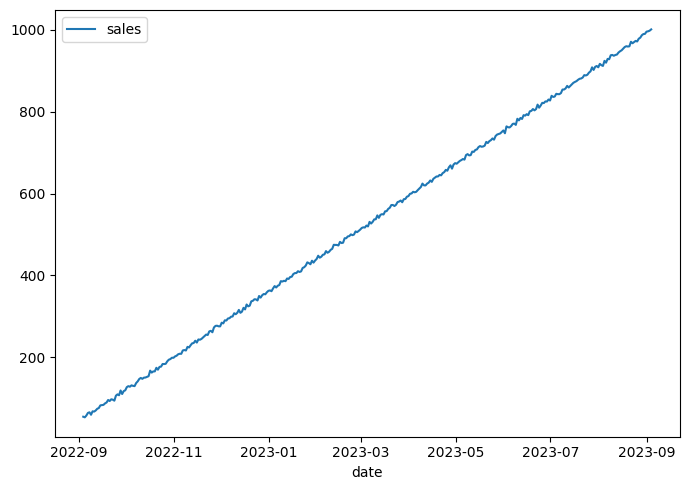

In [121]:
#Graficamos de manera rapida los datos
fig, axis = plt.subplots(figsize=(7, 5))
sns.lineplot(data=df)
plt.tight_layout()
plt.show()

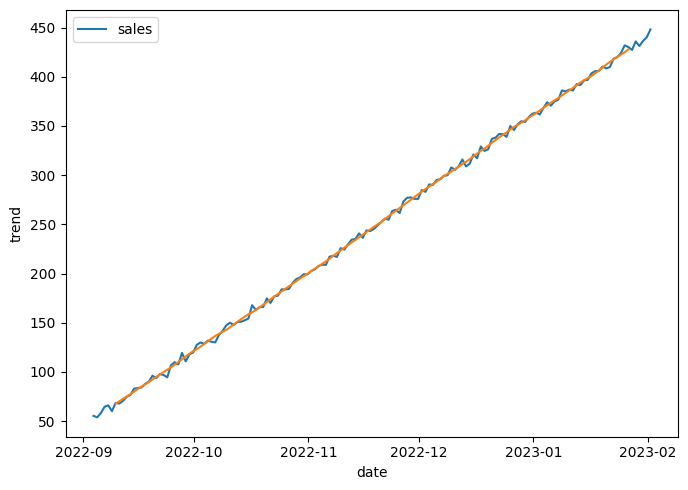

In [122]:
# Vamos a  aplicar lo que vimos en clases y vamos a descomponer la serie de tiempo para extraer la tendencia y la estacionalidad
# Vamos a hacer un poco de "zoom" con "df.loc" para ver mejor la linea que atraviesa la serie de tiempo, es decir la tendencia
df_aux = df.loc['2022-09-01' : '2023-02-01']
decomposition = seasonal_decompose(df, period = 12)
decomposition_aux = seasonal_decompose(df_aux, period = 12)
trend = decomposition_aux.trend
fig, axis = plt.subplots(figsize=(7, 5))
sns.lineplot(data = df_aux)
sns.lineplot(data = trend)
plt.tight_layout()
plt.show()

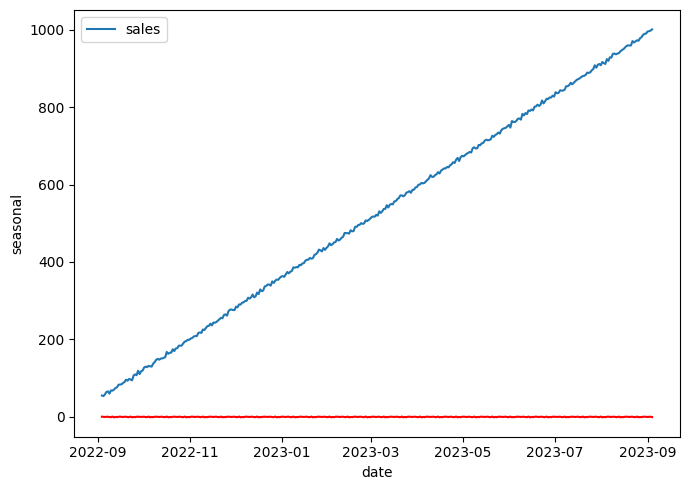

In [123]:
#Extraigo la estacionalidad de mi objeto descomposition ahora si "zoom"
seasonal = decomposition.seasonal
fig, axis = plt.subplots(figsize=(7, 5))
sns.lineplot(data=df)
sns.lineplot(data=seasonal, color = 'red')
plt.tight_layout()
plt.show()

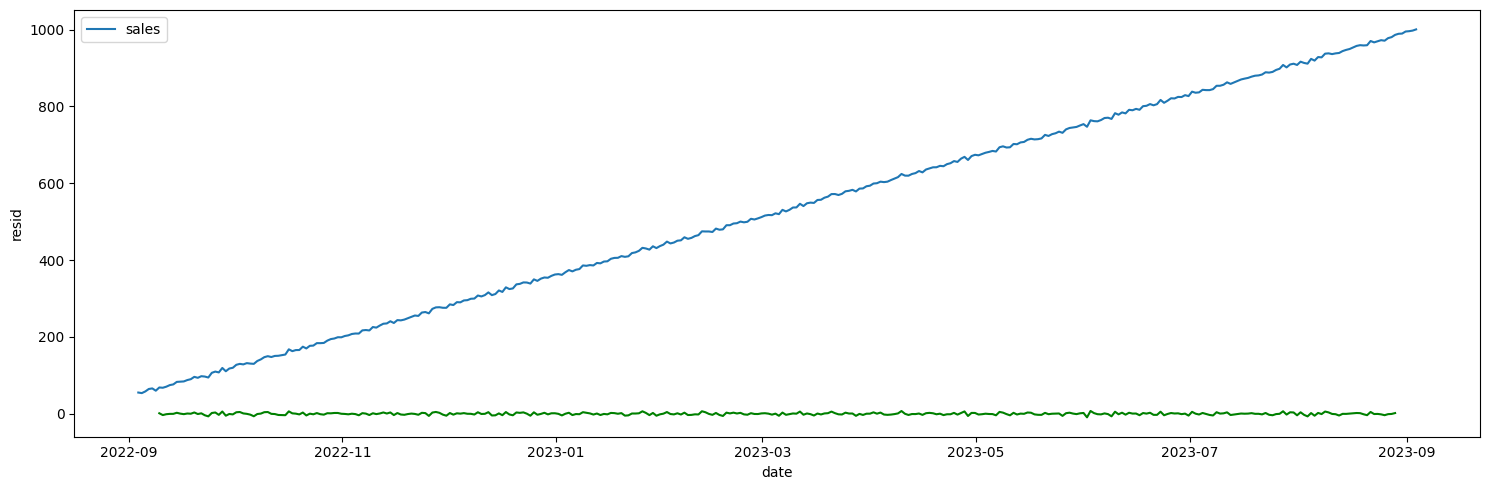

In [124]:
#No parece haber residual, pero vamos a graficarlo para ver que podemos encontrar
residual = decomposition.resid
fig, axis = plt.subplots(figsize=(15, 5))
sns.lineplot(data=df)
sns.lineplot(data=residual, color = 'green')
plt.tight_layout()
plt.show()

In [125]:
# En clases vimos como podemos hacer la prueba de Dickey-Fuller para saber si nuestra serie de tiempo es estacionaria o no, vamos a aplicarla a nuestro dataset
def test_stationarity(timeseries):
    print("Resultados de la Prueba Dickey-Fuller")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index = ['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    return dfoutput

test_stationarity(df)

Resultados de la Prueba Dickey-Fuller


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

# Analisis hasta ahora:
* Tenemos un fataframe con 366 filas, y 2 columnas `date` y `sales` que van desde el 2022-09-03 al 2023-09-03.
* Los dates incluyen hora.
* los `sales` son float y no hay nulos.
* **Tendencia**: Hay una tendencia positiva a medida que pasa el tiempo, Esto puede deberse a que el plan de accion en ventas que ha tomado la empresa desde su creacion a funcionado con creces,y a medida que se han dado a conocer ahan vendido mas y por ende producir mas.
* **Estacionalidad** y **ruido**: No se observa estacionalidad o patrones de cambios visibles ni un ruido(por lo menos considerable) que nos lo indique, Tampoco la prueba de Dickey-Fuller nos arrojo un p-value para que lo consideremos, posiblemente nuestro producto no dependa de la estacion anque solo estamos evaluando un año esto podria cambiar.
* **Outliers**: Tampoco podemos observar outliers la grafica nos indica casi una linea acendente perfecta sin desviaciones.
* **Puntos De Inflexion**: Como indicamos antes la linea acendente es estable no se desvia ni para arriba ni para abajo, las ventas han estado muy controladas.

In [126]:
# Hacemos el split de nuestros datos, pero esta ves no vamos a usar train_test_split, sino que vamos a hacer un split manual,para mantener el orden de los datos,
# ya que en las series de tiempo el orden de los datos es importante
X_train_size = int(len(df) * 0.8)
X_train = df.iloc[:X_train_size]
X_test = df.iloc[X_train_size:]

In [127]:
#Declaramos y entrenamos el ARIMA con auto_arima
model_arima = auto_arima(X_train["sales"], seasonal = False, trace = True)
model_arima.fit(X_train["sales"])
model_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1675.428, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1578.564, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1475.165, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1763.761, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1475.512, Time=0.12 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1475.495, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1479.028, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1762.924, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.794 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  292
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -734.582
Date:                Fri, 17 Apr 2026   AIC                           1475.165
Time:                        15:54:08   BIC                           1486.185
Sample:                    09-03-2022   HQIC                          1479.579
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5984      0.011    243.641      0.000       2.577       2.619
ma.L1         -0.9439      0.021    -44.117      0.000      -0.986      -0.902
sigma2         9.0537      0.817     11.084      0.000       7.453      10.655
===================================================================================
Ljung-Box (L1) (Q):                   1.34   Jarque-Bera (JB):                 1.24
Prob(Q):                              0.25   Prob(JB):                         0.54
Heteroskedasticity (H):               0.95   Skew:                             0.06
Prob(H) (two-sided):                  0.81   Kurtosis:                         2.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Interpretacion de metricas
* El modelo escoje ARIMA(0,1,1), el 0 nos indica que no necesita mirar los valores exactos de los días anteriores para predecir hoy.
* El 1 que las ventas no son estacionarias, pero es importante aclarar que pusimos "seasonal=False" asi que hay que ver esto con couidado.
* Y El segundo 1: nos dice que el modelo usa el error de la predicción de ayer para corregir la de hoy.
* Entre Otros datos voy a señalar los qu vi a lo que entendi de estas metricas puesto que aun no las comprendo del todo bien:
 * **Intercept = 2.59** : El modelo asume que en promedio las ventas suben en 2.59 cada dia.
 * **Prob(JB) = 0.54**: hasta donde tengo entendido si es mayor a 0.05 significa dentro de todo que los errores se distribuyen de forma normal, esto da un buen intervalo de confianza
 * **Prob(H) = 0.81**: Es otro valor que busca ser mayor a 0.05 indica la variabilidad de los errores.
 * y **Prob(Q) = 0.25 (Ljung-Box)**: Nos indica que si es mayor a 0.5 el modelo extrajo toda la info util en los datos, y que en teoria no hay patrones ocultos por asi decirlo.

In [128]:
# Hacemos la prediccion
forecast = model_arima.predict(n_periods = len(X_test))
forecast = pd.Series(forecast, index = X_test.index)
forecast

date
2023-06-22 17:10:08.079328    810.107776
2023-06-23 17:10:08.079328    812.706154
2023-06-24 17:10:08.079328    815.304531
2023-06-25 17:10:08.079328    817.902909
2023-06-26 17:10:08.079328    820.501287
                                 ...    
2023-08-30 17:10:08.079328    989.395832
2023-08-31 17:10:08.079328    991.994210
2023-09-01 17:10:08.079328    994.592587
2023-09-02 17:10:08.079328    997.190965
2023-09-03 17:10:08.079328    999.789343
Length: 74, dtype: float64

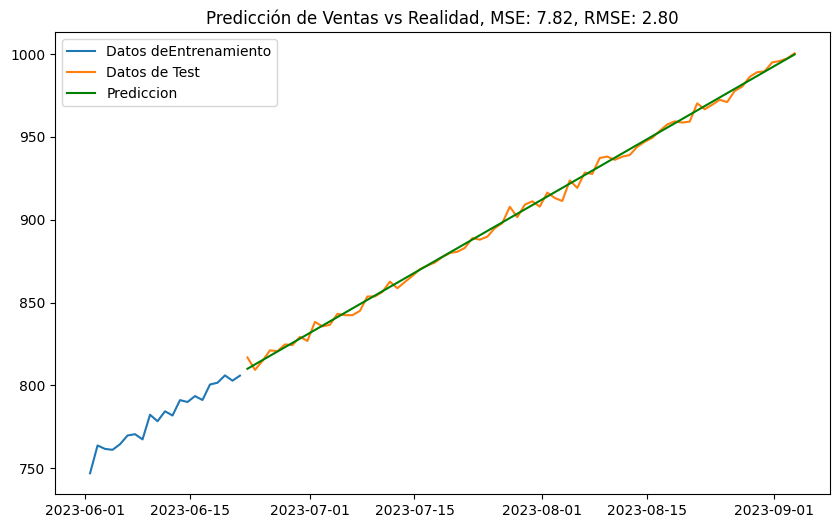

In [129]:
# Y Graficamos haciendo un poco de "Zoom" para ver mejor la prediccion vs la realidad
plt.figure(figsize=(10, 6))
X_train_aux= X_train.loc['2023-06-01':]
mse = mean_squared_error(X_test['sales'], forecast)
rmse = np.sqrt(mse)
plt.plot(X_train_aux['sales'], label='Datos deEntrenamiento')
plt.plot(X_test['sales'], label='Datos de Test')
plt.plot(forecast, label='Prediccion', color='green')
plt.title(f'Predicción de Ventas vs Realidad, MSE: {mse:.2f}, RMSE: {rmse:.2f}')
plt.legend()
plt.show()

# Conclusiones Finales:
Como Vemos en el grafico la prediccion(linea verde) se representa como una linea recta acendente(sin ruido), con respecto a los datos de prueba(linea naranja), Esto nos infica el camino que tomo el auto_arima para predecir mejor, como recordaremos el modelo escojio ARIMA(0,1,1), con un intercept de 2.59, asi que no es de extrañaser que el modelo ignore por asi decirlo el ruido como patrones, porque relamente no hay un patron muy marcado, en su lugar considera mejor mantener linealidad aumentando cada dia 2.59 del intercept, por otra parte tenemos un RMSE o error cuadratico medio de 2.80, esta variacion es muy buena teniendo en cuenta que estamos tratando con valores de venteas entre 200-1000 uniddades aprox, por lo que en terminos practicos 2.80 no representa casi nada.

In [130]:
#Guardamos el arima
model_pack = {
    'model_arima': model_arima,
    'x_train': X_train,
    'x_test': X_test,
  
}
path = f"../data/processed/models/arima/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}models_pack.pkl')

['../data/processed/models/arima/models_pack.pkl']